# EDA (Electrodermal Activity)

- Known as **galvanic skin responses or skin conductance**
- Measures (in microsiemens $ \mu S $) how well skin conducts electricity at any given moment
    1. Indicator/Objective assessment of emotional (e.g. stressed, excited, etc) arousal $ \rightarrow $ sweat glands produce moisure (even if don't feel sweaty)
        1. Baseline: Normal EDA, with respect to subject
        2. Stressed: EDA spikes bc...
        3. Amusement: ...
        4. Meditation: EDA drops 
    2. Increased perspiration [ ] increases skin conductance
    3. Physiological indicator of sympathetic nervous system activation (e.g. fight-flight response)
        1. EDA is a quant functional measure of **sudomotor** activity  $ \rightarrow $ **sudomotor** is connected **sympathetic** function, thus can evaluate autonomic (sympathetic and parasympathetic) function.

## References
1. AI: claude-4.5-sonnet
2. YT: [Psychophysiology: Galvanic skin conductance (GSC) or electrodermal activity (EDA) | Noldus](https://youtu.be/-KupdgJERng?si=h4iBR6-_AgPBzzwX)
3. PAPER: [Innovations in Electrodermal Activity Data Collection and Signal Processing: A Systematic Review](https://github.com/roeh-health/lamina/blob/general_wesad_analysis/papers/innovationsInElectrodermalActivityDataCollectionAndSignalProcessingSystematicReview.pdf)

In [35]:
import os
import sys

import numpy as np
import pandas as pd

notebook_dir = os.getcwd()

sys.path.append(os.path.join(notebook_dir, '../signal'))

from data_processing import DataProcessing

## Load Data

In [2]:
base_data_path = DataProcessing.load_base_data_path(notebook_dir)
data_path = os.path.join(base_data_path, 'WESAD/all_subjects/chest.csv')
df = DataProcessing.load_from_file(data_path, file_type='csv')
df.drop(['Unnamed: 0'], axis=1, inplace=True)
df

,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
0,0.9554,-0.2220,-0.5580,0.021423,-0.004440,5.250549,30.120758,-1.148987,S2,0
1,0.9258,-0.2216,-0.5538,0.020325,0.004349,5.267334,30.129517,-1.124573,S2,0
2,0.9082,-0.2196,-0.5392,0.016525,0.005173,5.243301,30.138214,-1.152039,S2,0
3,0.8974,-0.2102,-0.5122,0.016708,0.007187,5.249405,30.129517,-1.158142,S2,0
4,0.8882,-0.2036,-0.4824,0.011673,-0.015152,5.286407,30.130950,-1.161194,S2,0
...,...,...,...,...,...,...,...,...,...,...
60807595,0.9006,-0.0400,-0.1898,0.173676,-0.005539,7.265091,33.862762,0.318909,S17,0
60807596,0.9022,-0.0398,-0.1872,0.168777,-0.004944,7.266617,33.859740,0.233459,S17,0
60807597,0.9028,-0.0424,-0.1864,0.167130,-0.016068,7.262802,33.864290,0.318909,S17,0
60807598,0.9002,-0.0408,-0.1854,0.170334,0.005173,7.269669,33.862762,0.308228,S17,0


In [3]:
copy_df = df.copy()
copy_df

,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
0,0.9554,-0.2220,-0.5580,0.021423,-0.004440,5.250549,30.120758,-1.148987,S2,0
1,0.9258,-0.2216,-0.5538,0.020325,0.004349,5.267334,30.129517,-1.124573,S2,0
2,0.9082,-0.2196,-0.5392,0.016525,0.005173,5.243301,30.138214,-1.152039,S2,0
3,0.8974,-0.2102,-0.5122,0.016708,0.007187,5.249405,30.129517,-1.158142,S2,0
4,0.8882,-0.2036,-0.4824,0.011673,-0.015152,5.286407,30.130950,-1.161194,S2,0
...,...,...,...,...,...,...,...,...,...,...
60807595,0.9006,-0.0400,-0.1898,0.173676,-0.005539,7.265091,33.862762,0.318909,S17,0
60807596,0.9022,-0.0398,-0.1872,0.168777,-0.004944,7.266617,33.859740,0.233459,S17,0
60807597,0.9028,-0.0424,-0.1864,0.167130,-0.016068,7.262802,33.864290,0.318909,S17,0
60807598,0.9002,-0.0408,-0.1854,0.170334,0.005173,7.269669,33.862762,0.308228,S17,0


## Keep Meaningful Labels

- 0 = not defined / transient
- 1 = baseline
- 2 = stress
- 3 = amusement
- 4 = meditation
- 5/6/7 = should be ignored in this dataset

In [4]:
filt_labels = copy_df['label'].isin([0, 5, 6, 7])
copy_df = copy_df[~filt_labels]
copy_df

,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
214583,0.8914,-0.1102,-0.2576,0.030945,-0.003708,5.710983,29.083618,1.191711,S2,1
214584,0.8926,-0.1086,-0.2544,0.033646,-0.014145,5.719376,29.122437,1.139832,S2,1
214585,0.8930,-0.1094,-0.2580,0.033005,0.010208,5.706406,29.115234,1.141357,S2,1
214586,0.8934,-0.1082,-0.2538,0.031815,0.012634,5.712509,29.126709,1.155090,S2,1
214587,0.8930,-0.1096,-0.2570,0.030350,0.002060,5.727005,29.100860,1.133728,S2,1
...,...,...,...,...,...,...,...,...,...,...
60620859,0.4826,-0.0094,-0.8248,0.195236,0.013962,7.021713,34.080353,14.350891,S17,4
60620860,0.4838,-0.0088,-0.8298,0.178574,0.013504,7.020569,34.084900,14.419556,S17,4
60620861,0.4872,-0.0086,-0.8294,0.158020,0.024353,7.020569,34.022460,14.363098,S17,4
60620862,0.4858,-0.0080,-0.8376,0.129959,0.004623,7.029724,34.063538,14.361572,S17,4


## Signal of Interest

In [5]:
signal_name = 'EDA'
signal_df = copy_df.loc[:, [signal_name, 'subject', 'label']]
signal_df

,EDA,subject,label
214583,5.710983,S2,1
214584,5.719376,S2,1
214585,5.706406,S2,1
214586,5.712509,S2,1
214587,5.727005,S2,1
...,...,...,...
60620859,7.021713,S17,4
60620860,7.020569,S17,4
60620861,7.020569,S17,4
60620862,7.029724,S17,4


## Clean Data

In [6]:
import neurokit2 as nk
def get_cleaned_eda(df, col_name, hz: int = 700):
    df = df.copy()
    cleaned_series = nk.eda_clean(df[col_name], hz)
    df[f'Cleaned {col_name}'] = cleaned_series

    return df

In [7]:
# cleaned_signal_df = DataProcessing.get_cleaned_data(signal_df, signal_name, 700)
cleaned_signal_df = get_cleaned_eda(signal_df, signal_name, 700)
cleaned_signal_df

,EDA,subject,label,Cleaned EDA
214583,5.710983,S2,1,5.713918
214584,5.719376,S2,1,5.713804
214585,5.706406,S2,1,5.713689
214586,5.712509,S2,1,5.713573
214587,5.727005,S2,1,5.713455
...,...,...,...,...
60620859,7.021713,S17,4,7.025344
60620860,7.020569,S17,4,7.025344
60620861,7.020569,S17,4,7.025344
60620862,7.029724,S17,4,7.025344


## Set each subject with new row 0

In [8]:
new_signal_df = DataProcessing.reset_rows(cleaned_signal_df)
new_signal_df

,EDA,subject,label,Cleaned EDA
0,5.710983,S2,1,5.713918
1,5.719376,S2,1,5.713804
2,5.706406,S2,1,5.713689
3,5.712509,S2,1,5.713573
4,5.727005,S2,1,5.713455
...,...,...,...,...
2104895,7.021713,S17,4,7.025344
2104896,7.020569,S17,4,7.025344
2104897,7.020569,S17,4,7.025344
2104898,7.029724,S17,4,7.025344


In [9]:
subjects = new_signal_df['subject'].unique()
subjects

array(['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11',
       'S13', 'S14', 'S15', 'S16', 'S17'], dtype=object)

In [ ]:
def check_label_order(s_df):
    # s is a Series here
    s = s_df.loc[s_df['label'].isin([3, 4]), 'label']

    run_starts = s[s.ne(s.shift())]
    run_order = run_starts.to_numpy()

    # print(type(run_order))
    return run_order

In [ ]:
for subject in subjects:
    print(subject)

    s_df = DataProcessing.get_specific_subject_df(new_signal_df, subject)
    order = check_label_order(s_df)
    print(order)

    normal = np.array_equal(order, [3, 4])
    abnormal = np.array_equal(order, [4, 3, 4])

    print(f"Normal Label Order: {normal}")
    print(f"Abnormal Label Order: {abnormal}")

S2
[4 3 4]
Normal: False
Abnormal: True
S3
[4 3 4]
Normal: False
Abnormal: True
S4
[3 4]
Normal: True
Abnormal: False
S5
[3 4]
Normal: True
Abnormal: False
S6
[4 3 4]
Normal: False
Abnormal: True
S7
[3 4]
Normal: True
Abnormal: False
S8
[3 4]
Normal: True
Abnormal: False
S9
[4 3 4]
Normal: False
Abnormal: True
S10
[3 4]
Normal: True
Abnormal: False
S11
[4 3 4]
Normal: False
Abnormal: True
S13
[3 4]
Normal: True
Abnormal: False
S14
[4 3 4]
Normal: False
Abnormal: True
S15
[3 4]
Normal: True
Abnormal: False
S16
[4 3 4]
Normal: False
Abnormal: True
S17
[3 4]
Normal: True
Abnormal: False


### Ex to get specific subject

In [12]:
s_df = DataProcessing.get_specific_subject_df(new_signal_df, 'S4')
s_df

,EDA,subject,label,Cleaned EDA
0,1.343536,S4,1,4.188673
1,1.316452,S4,1,4.137287
2,1.325989,S4,1,4.085922
3,1.280975,S4,1,4.034594
4,1.357651,S4,1,3.983319
...,...,...,...,...
2078996,2.528763,S4,4,4.310937
2078997,2.527237,S4,4,4.344715
2078998,2.539825,S4,4,4.378528
2078999,2.535248,S4,4,4.412368


In [13]:
labels = new_signal_df['label'].unique()
labels

array([1, 2, 4, 3])

In [14]:
s_df.drop(columns=['subject'], inplace=True)

/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_41923/2951368449.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s_df.drop(columns=['subject'], inplace=True)


In [15]:
def filt_label_data(label):
    filt_label_df = (s_df['label'] == label)
    return s_df[filt_label_df]

In [16]:
label_dfs = []
for label in labels:
    label_df = filt_label_data(label)
    label_dfs.append(label_df)

In [17]:
baseline_df = label_dfs[0]
baseline_df

,EDA,label,Cleaned EDA
0,1.343536,1,4.188673
1,1.316452,1,4.137287
2,1.325989,1,4.085922
3,1.280975,1,4.034594
4,1.357651,1,3.983319
...,...,...,...
810596,1.306152,1,1.331067
810597,1.304245,1,1.331420
810598,1.298141,1,1.331773
810599,1.300430,1,1.332127


In [18]:
# baseline_df.drop(columns=['label'], inplace=True)

In [19]:
# baseline_df.plot()

## Convert EDA Indicies to Time

In [20]:
baseline_time_df = DataProcessing.create_time_df(baseline_df, 700)
baseline_time_df

,EDA,label,Cleaned EDA,Milliseconds,Seconds,Time
0,1.343536,1,4.188673,0.00,0.00000,0 days 00:00:00
1,1.316452,1,4.137287,1.43,0.00143,0 days 00:00:00
2,1.325989,1,4.085922,2.86,0.00286,0 days 00:00:00
3,1.280975,1,4.034594,4.29,0.00429,0 days 00:00:00
4,1.357651,1,3.983319,5.71,0.00571,0 days 00:00:00.010000
...,...,...,...,...,...,...
810596,1.306152,1,1.331067,1157994.29,1157.99429,0 days 00:19:17.990000
810597,1.304245,1,1.331420,1157995.71,1157.99571,0 days 00:19:18
810598,1.298141,1,1.331773,1157997.14,1157.99714,0 days 00:19:18
810599,1.300430,1,1.332127,1157998.57,1157.99857,0 days 00:19:18


## Split into Segments

- 60 seconds to follow example 
    1. WIKI: [EDA example](https://en.wikipedia.org/wiki/Electrodermal_activity)
        - 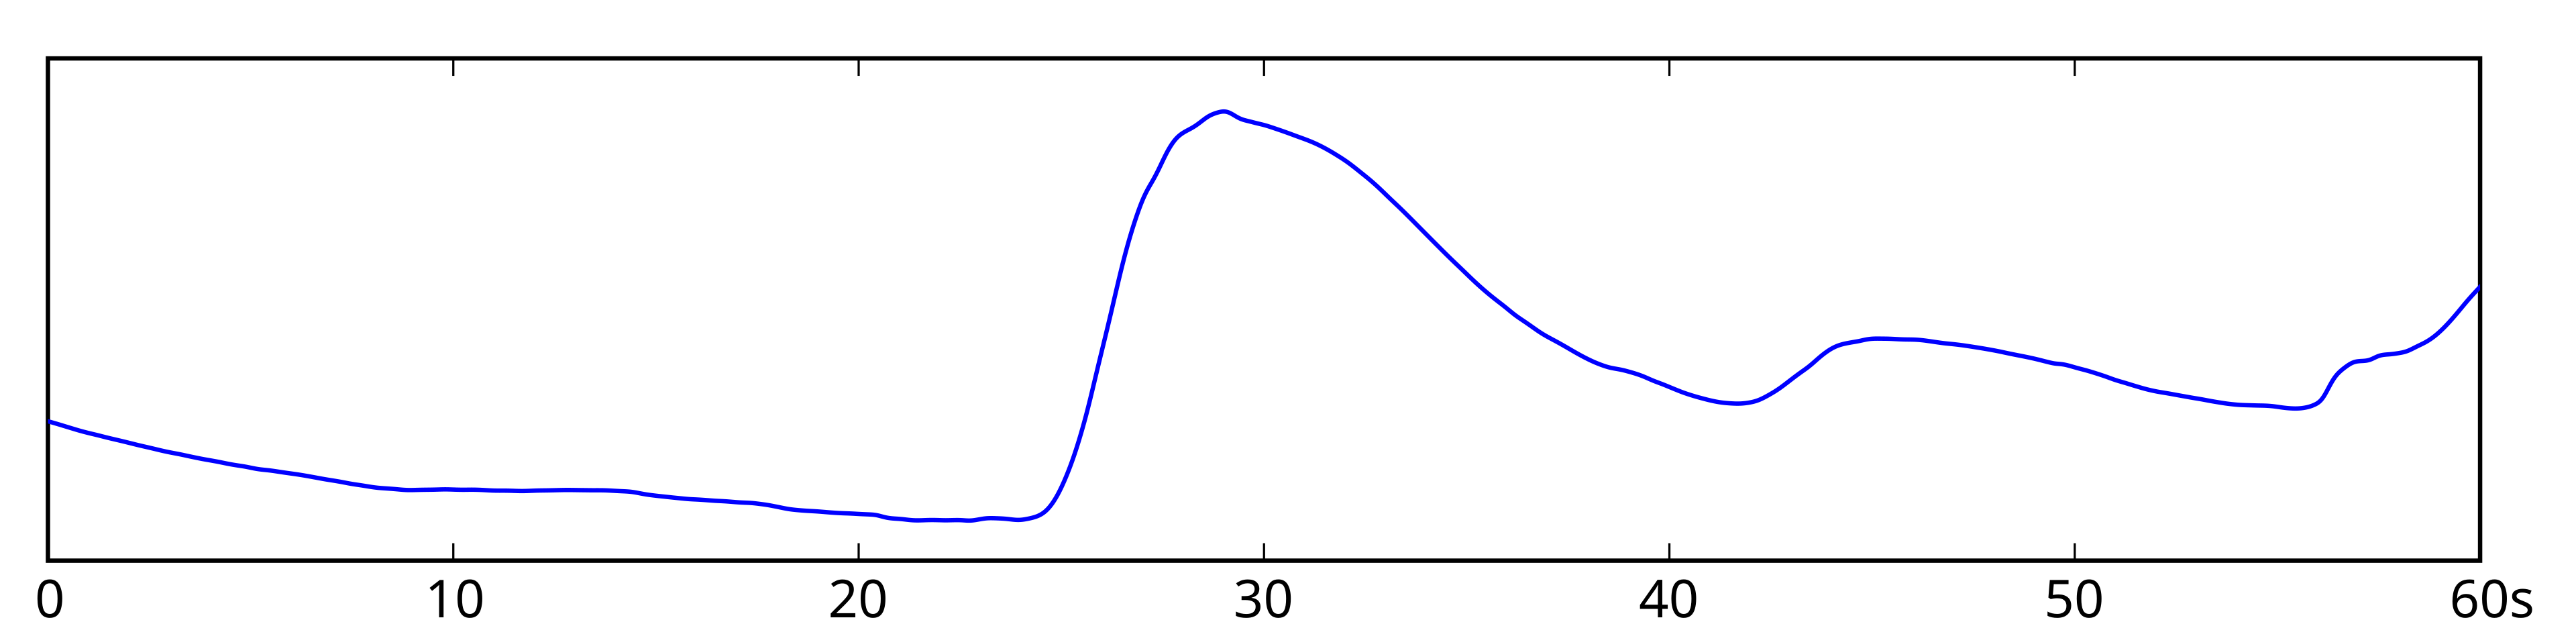
    2. PAPER: [Innovations in Electrodermal Activity Data Collection and Signal Processing: A Systematic Review](https://github.com/roeh-health/lamina/blob/general_wesad_analysis/papers/innovationsInElectrodermalActivityDataCollectionAndSignalProcessingSystematicReview.pdf)
        - 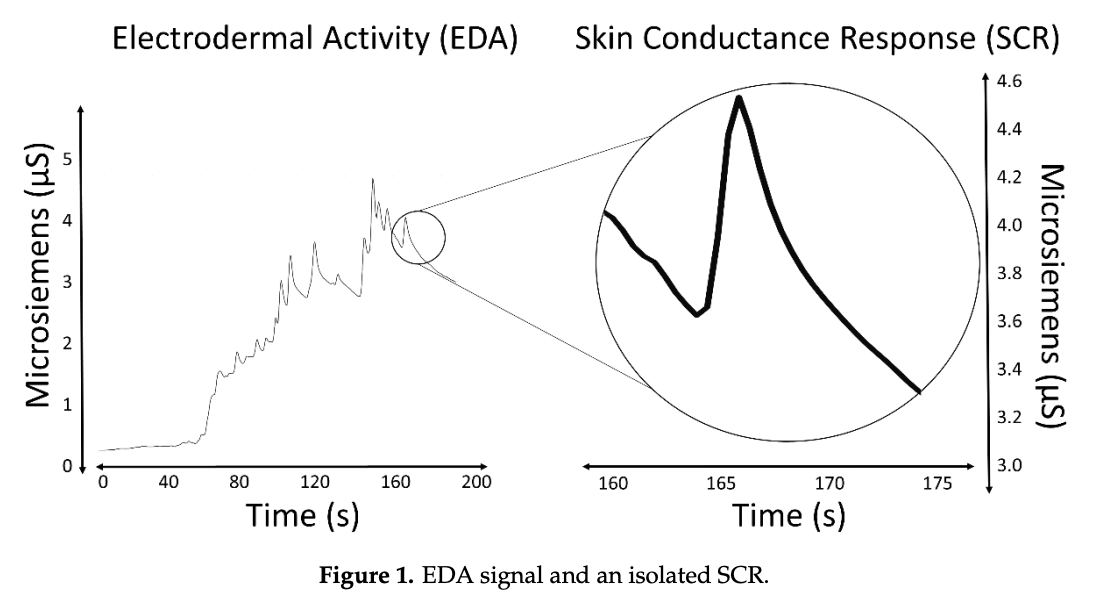
        - The most salient characteristic of an EDA signal is the occurrence of skin conductance responses (SCRs) resulting from an underlying sympathetic reaction to a stimulus. The SCRs are the rapid and smooth transient events noticeable in the EDA signal (Figure 1).
        - 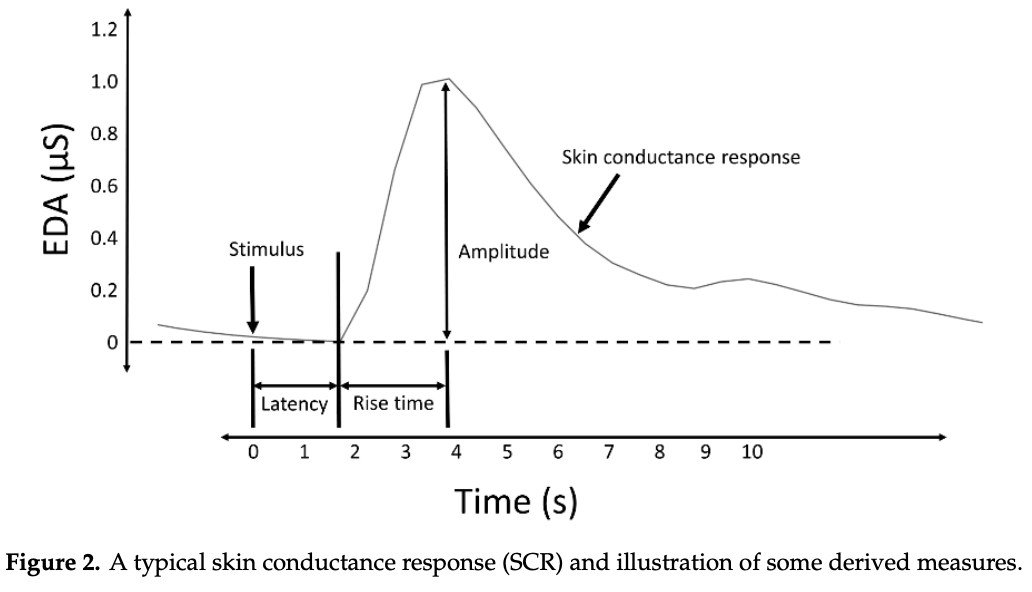
        - 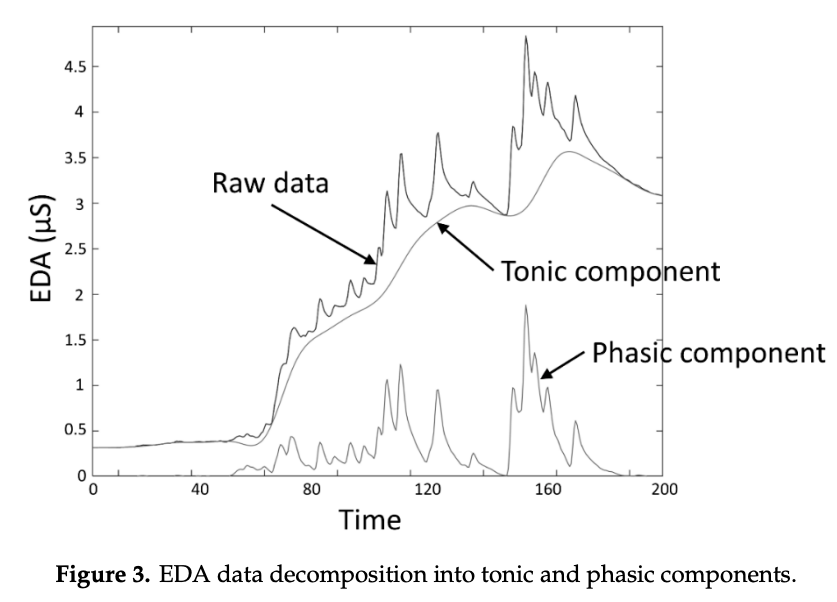


In [21]:
segment_baseline_df, per_window_df = DataProcessing.get_segments_by_duration(baseline_time_df, 60)
segment_baseline_df

,EDA,label,Cleaned EDA,Milliseconds,Seconds,Time,window_id,window_start_seconds,window_end_seconds
0,1.343536,1,4.188673,0.00,0.00000,0 days 00:00:00,0,0,60
1,1.316452,1,4.137287,1.43,0.00143,0 days 00:00:00,0,0,60
2,1.325989,1,4.085922,2.86,0.00286,0 days 00:00:00,0,0,60
3,1.280975,1,4.034594,4.29,0.00429,0 days 00:00:00,0,0,60
4,1.357651,1,3.983319,5.71,0.00571,0 days 00:00:00.010000,0,0,60
...,...,...,...,...,...,...,...,...,...
810596,1.306152,1,1.331067,1157994.29,1157.99429,0 days 00:19:17.990000,19,1140,1200
810597,1.304245,1,1.331420,1157995.71,1157.99571,0 days 00:19:18,19,1140,1200
810598,1.298141,1,1.331773,1157997.14,1157.99714,0 days 00:19:18,19,1140,1200
810599,1.300430,1,1.332127,1157998.57,1157.99857,0 days 00:19:18,19,1140,1200


In [22]:
window_ids = segment_baseline_df['window_id'].unique()
window_ids

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19])

### Plot each window

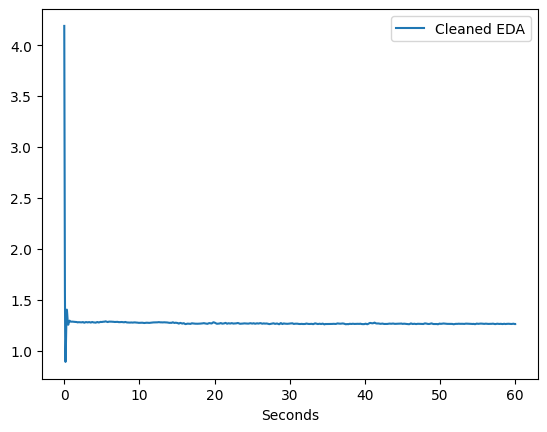

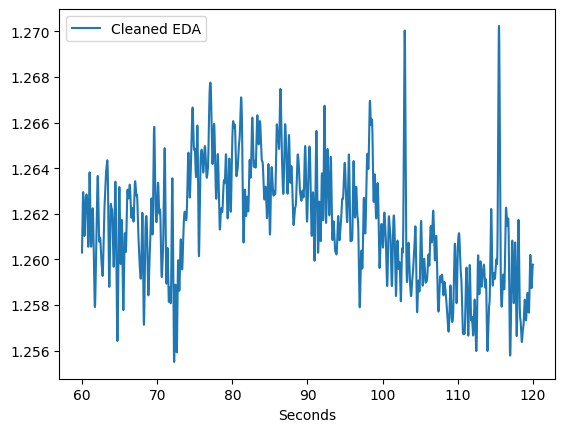

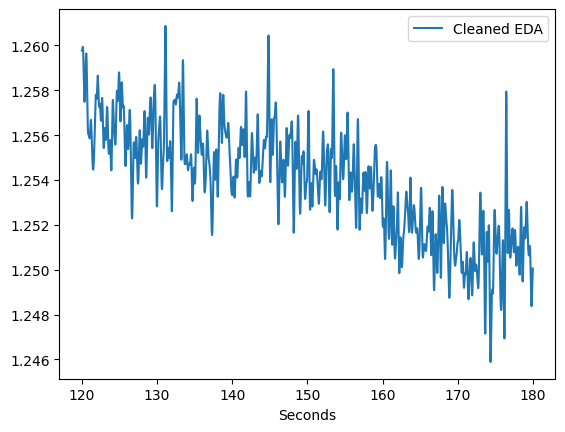

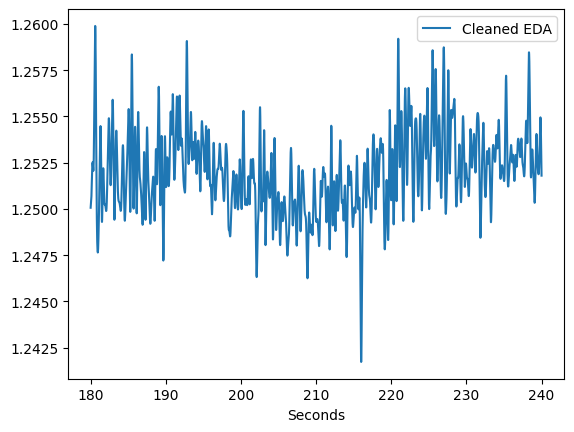

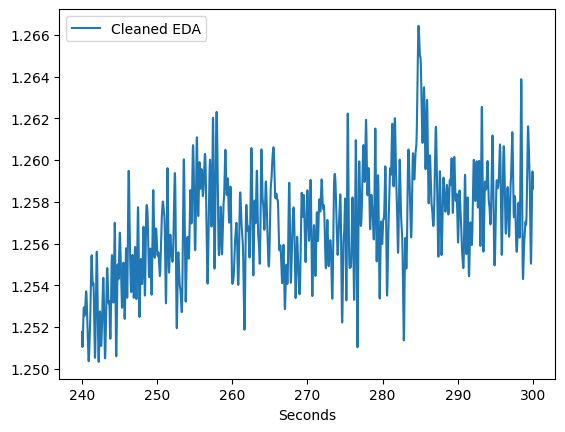

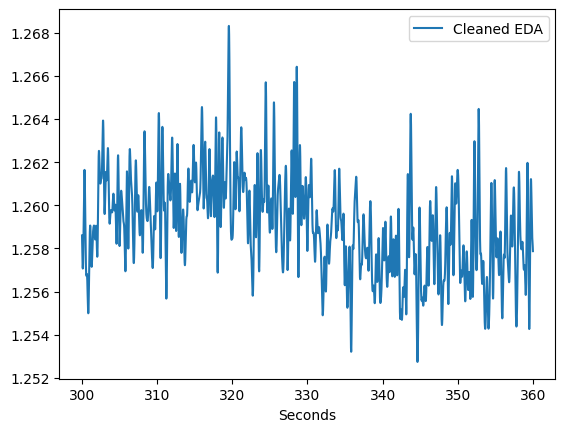

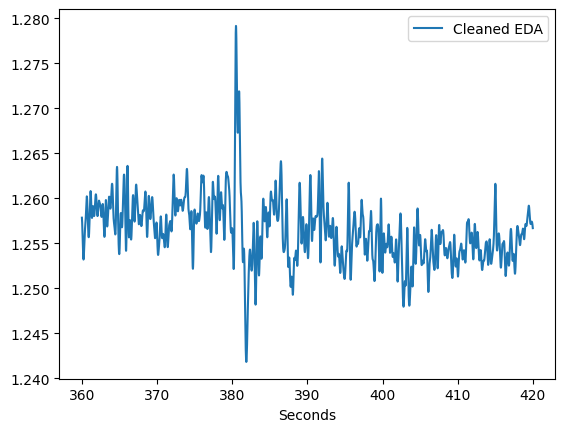

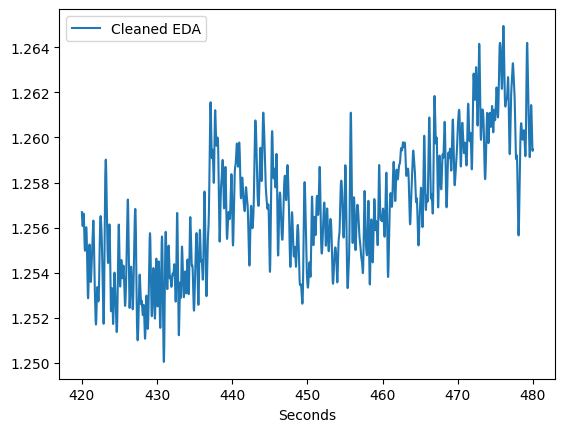

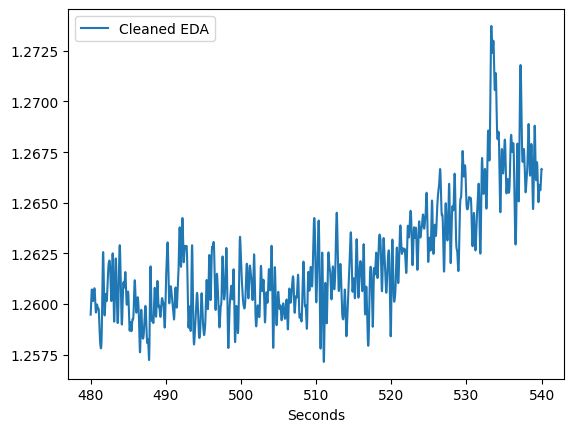

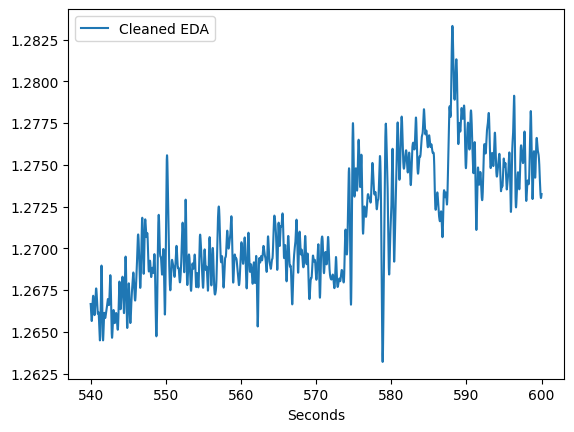

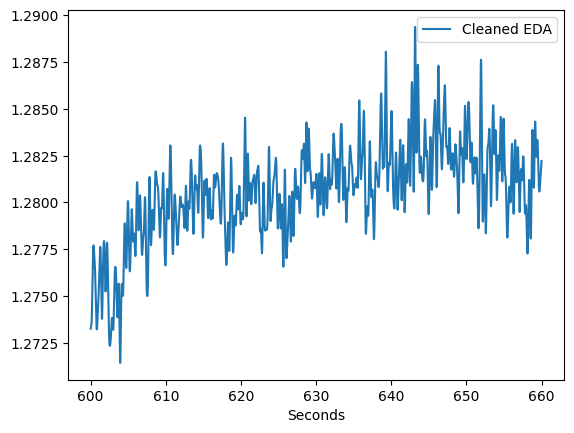

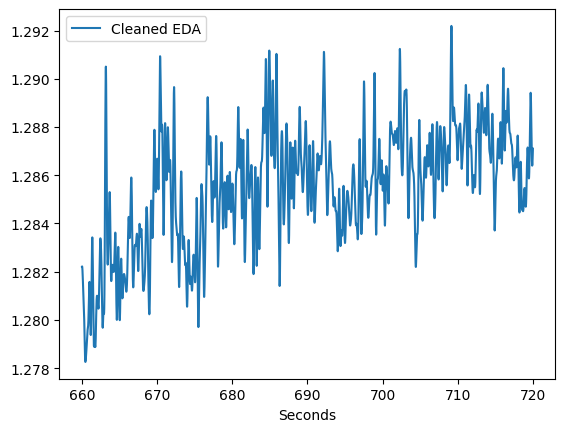

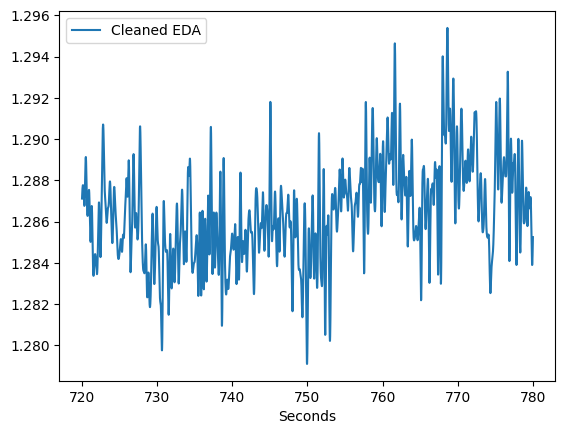

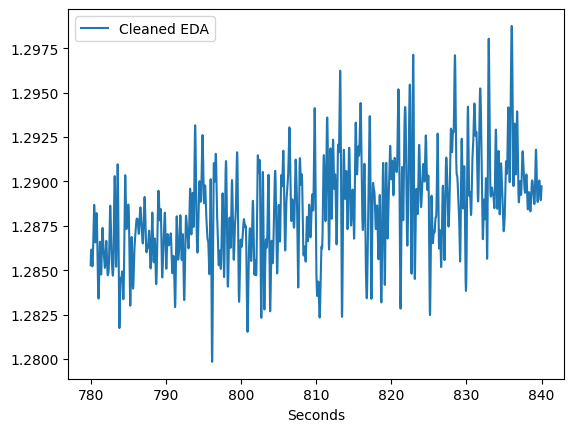

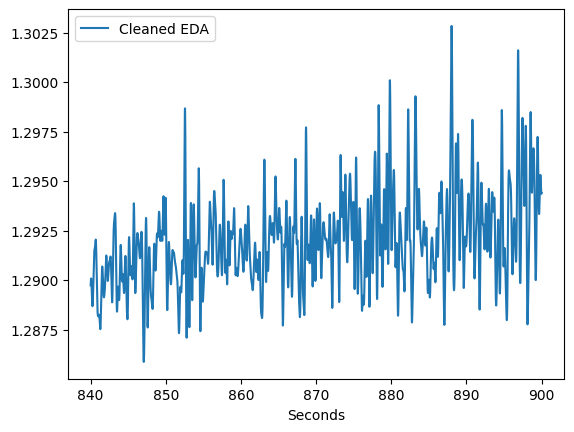

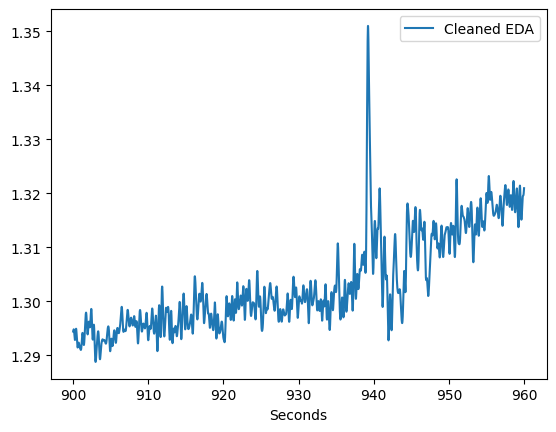

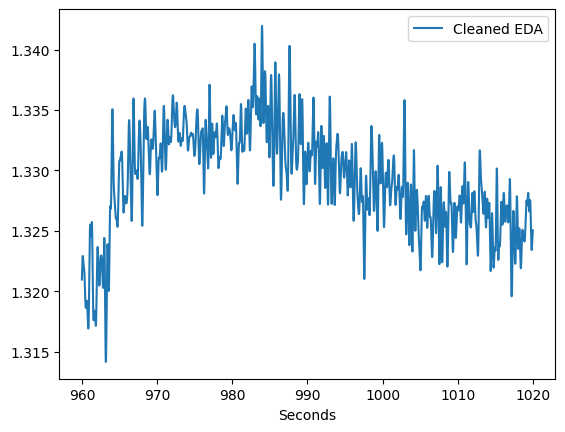

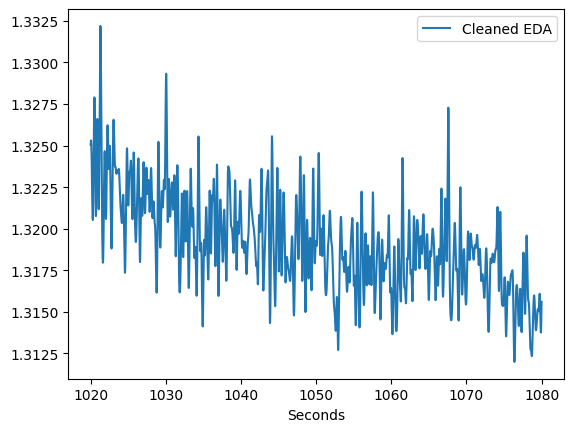

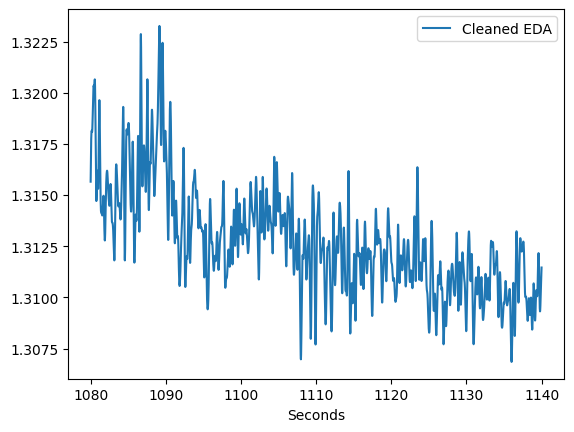

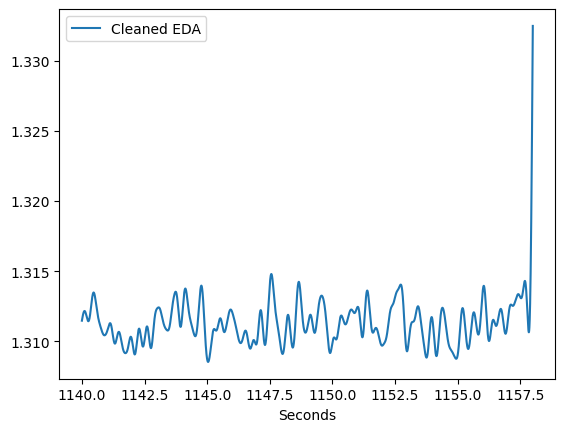

In [23]:
for window_id in window_ids:
    filt_window = (segment_baseline_df['window_id'] == window_id)
    window_df = segment_baseline_df[filt_window]
    window_df.plot(x='Seconds', y='Cleaned EDA')

## All Variables

1. 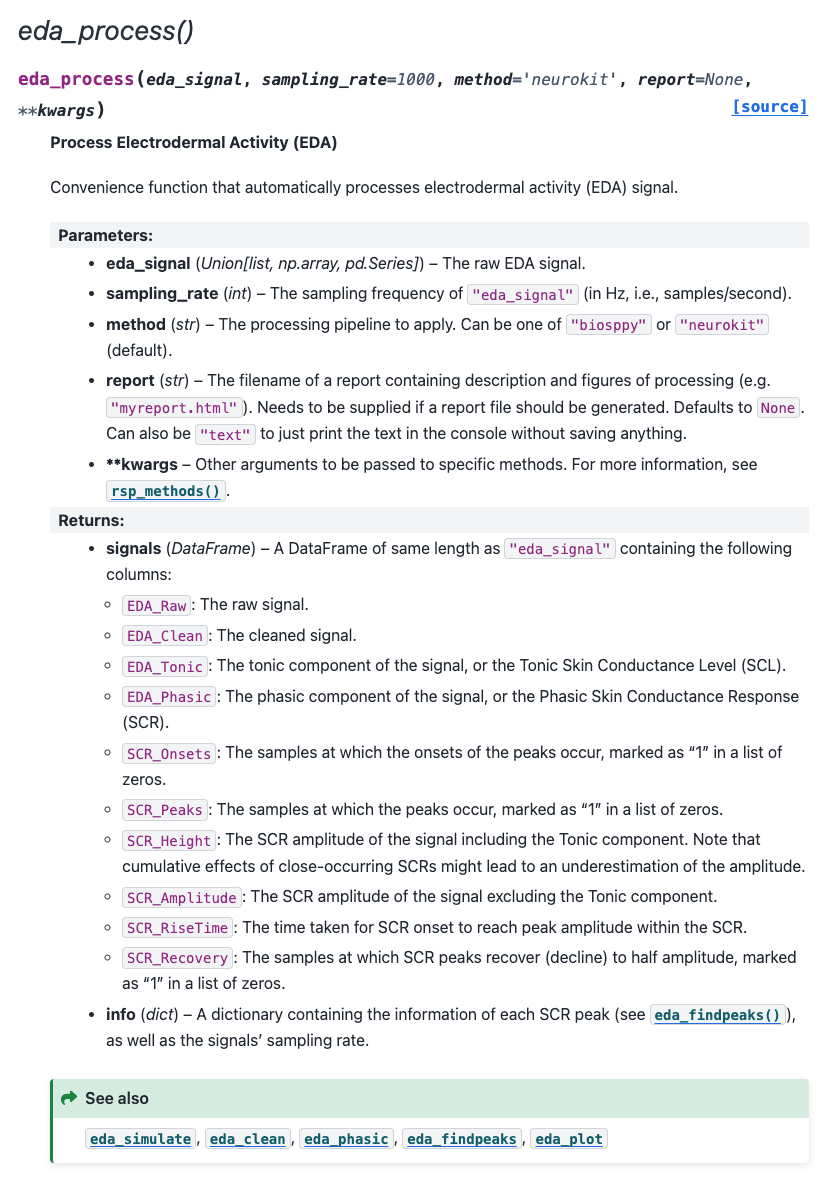
2. Use `eda_analyze()` for event-related. Seems like it may find our labels of baseline, stress, amusement, and meditation
    1. Put first 60 sections into single DF
    2. Pass to this function to see if can recognize labels

In [24]:
filt_window = (segment_baseline_df['window_id'] == 0)
df = segment_baseline_df[filt_window]
df

,EDA,label,Cleaned EDA,Milliseconds,Seconds,Time,window_id,window_start_seconds,window_end_seconds
0,1.343536,1,4.188673,0.00,0.00000,0 days 00:00:00,0,0,60
1,1.316452,1,4.137287,1.43,0.00143,0 days 00:00:00,0,0,60
2,1.325989,1,4.085922,2.86,0.00286,0 days 00:00:00,0,0,60
3,1.280975,1,4.034594,4.29,0.00429,0 days 00:00:00,0,0,60
4,1.357651,1,3.983319,5.71,0.00571,0 days 00:00:00.010000,0,0,60
...,...,...,...,...,...,...,...,...,...
41995,1.258087,1,1.260217,59992.86,59.99286,0 days 00:00:59.990000,0,0,60
41996,1.250839,1,1.260233,59994.29,59.99429,0 days 00:00:59.990000,0,0,60
41997,1.314545,1,1.260249,59995.71,59.99571,0 days 00:01:00,0,0,60
41998,1.283646,1,1.260267,59997.14,59.99714,0 days 00:01:00,0,0,60


In [25]:
raw_eda = df['EDA']
raw_eda

0        1.343536
1        1.316452
2        1.325989
3        1.280975
4        1.357651
           ...   
41995    1.258087
41996    1.250839
41997    1.314545
41998    1.283646
41999    1.266861
Name: EDA, Length: 42000, dtype: float64

In [26]:
signals, info = nk.eda_process(raw_eda, 700)

In [27]:
signals

,EDA_Raw,EDA_Clean,EDA_Tonic,EDA_Phasic,SCR_Onsets,SCR_Peaks,SCR_Height,SCR_Amplitude,SCR_RiseTime,SCR_Recovery,SCR_RecoveryTime
0,1.343536,1.349692,1.320550,0.029142,0,0,0.0,0.0,0.0,0,0.0
1,1.316452,1.348636,1.320538,0.028099,0,0,0.0,0.0,0.0,0,0.0
2,1.325989,1.347581,1.320525,0.027056,0,0,0.0,0.0,0.0,0,0.0
3,1.280975,1.346525,1.320512,0.026013,0,0,0.0,0.0,0.0,0,0.0
4,1.357651,1.345471,1.320500,0.024971,0,0,0.0,0.0,0.0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
41995,1.258087,1.262316,1.262401,0.000001,0,0,0.0,0.0,0.0,0,0.0
41996,1.250839,1.262315,1.262401,0.000001,0,0,0.0,0.0,0.0,0,0.0
41997,1.314545,1.262315,1.262401,0.000001,0,0,0.0,0.0,0.0,0,0.0
41998,1.283646,1.262315,1.262401,0.000001,0,0,0.0,0.0,0.0,0,0.0


In [28]:
info

{'SCR_Onsets': array([  120,   740,  1582,  1857,  2160,  2452,  2905,  3673,  4235,
         4671,  5094,  5533,  6051,  6338,  6923,  7406,  8634,  9124,
         9966, 10235, 10654, 10981, 11293, 11733, 12822, 13297, 13690,
        14348, 14720, 15172, 15442, 15757, 16547, 17126, 17501, 17775,
        18085, 18449, 18692, 19338, 19635, 19994, 20319, 21098, 21573,
        21978, 22398, 22804, 23162, 23620, 23919, 24902, 25234, 25710,
        26184, 26736, 27427, 27878, 28218, 28715, 29415, 30047, 30417,
        31223, 31522, 32103, 32451, 33052, 33417, 33928, 34562, 34791,
        35078, 36568, 37246, 37993, 38259, 38565, 39081, 39753, 40100,
        40791, 41090]),
 'SCR_Peaks': array([  267,  1106,  1729,  2040,  2323,  2600,  3072,  3843,  4343,
         4915,  5316,  5688,  6215,  6568,  7214,  7707,  8773,  9265,
        10106, 10351, 10805, 11113, 11542, 11894, 12991, 13511, 13905,
        14566, 15005, 15314, 15591, 16150, 16750, 17351, 17630, 17947,
        18266, 18579, 1880

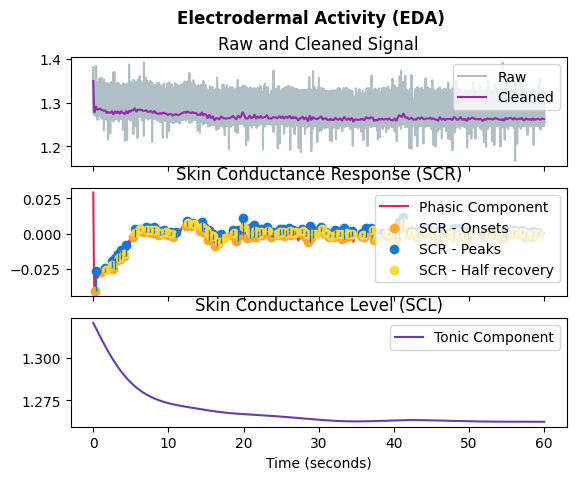

In [29]:
nk.eda_plot(signals, info)

## Peaks

In [36]:
segment_baseline_df

,EDA,label,Cleaned EDA,Milliseconds,Seconds,Time,window_id,window_start_seconds,window_end_seconds
0,1.343536,1,4.188673,0.00,0.00000,0 days 00:00:00,0,0,60
1,1.316452,1,4.137287,1.43,0.00143,0 days 00:00:00,0,0,60
2,1.325989,1,4.085922,2.86,0.00286,0 days 00:00:00,0,0,60
3,1.280975,1,4.034594,4.29,0.00429,0 days 00:00:00,0,0,60
4,1.357651,1,3.983319,5.71,0.00571,0 days 00:00:00.010000,0,0,60
...,...,...,...,...,...,...,...,...,...
810596,1.306152,1,1.331067,1157994.29,1157.99429,0 days 00:19:17.990000,19,1140,1200
810597,1.304245,1,1.331420,1157995.71,1157.99571,0 days 00:19:18,19,1140,1200
810598,1.298141,1,1.331773,1157997.14,1157.99714,0 days 00:19:18,19,1140,1200
810599,1.300430,1,1.332127,1157998.57,1157.99857,0 days 00:19:18,19,1140,1200


In [30]:
# clean_eda = df['Cleaned EDA']
clean_eda = segment_baseline_df['Cleaned EDA']

# clean_eda = segment_baseline_df.loc[:3000, 'Cleaned EDA']
clean_eda

0         4.188673
1         4.137287
2         4.085922
3         4.034594
4         3.983319
            ...   
810596    1.331067
810597    1.331420
810598    1.331773
810599    1.332127
810600    1.332481
Name: Cleaned EDA, Length: 810601, dtype: float64

## Tonic vs Phasic

- Tonic [slow acting]
    - **Measures:** Skin Conductance Level (SCL)
    - **About:** Constantly changes within individual, thus simply averaging is woefully inadequate
- Phasic [faster changing]
    - **Measures:** Skin Conductance Response (SCR)
    - **About:** Used to find peaks

References
1. TECHNICAL REPORT: A Guide for Analysing Electrodermal Activity (EDA) & Skin Conductance Responses (SCRs) for Psychological Experiments by Braithwaite et al., (2013)

In [31]:
eda_df = nk.eda_phasic(clean_eda, 700)
eda_df

,EDA_Tonic,EDA_Phasic
0,2.975998,1.212675
1,2.975464,1.161823
2,2.974929,1.110993
3,2.974394,1.060200
4,2.973860,1.009459
...,...,...
810596,1.311273,-0.004383
810597,1.311273,-0.004045
810598,1.311273,-0.003707
810599,1.311273,-0.003368


In [37]:
eda_phasic = eda_df["EDA_Phasic"]
eda_phasic

0         1.212675
1         1.161823
2         1.110993
3         1.060200
4         1.009459
            ...   
810596   -0.004383
810597   -0.004045
810598   -0.003707
810599   -0.003368
810600   -0.003029
Name: EDA_Phasic, Length: 810601, dtype: float64

In [ ]:
_, neurokit = nk.eda_peaks(eda_phasic, sampling_rate=700, method="neurokit")
_, kim2004 = nk.eda_peaks(eda_phasic, sampling_rate=700, method="kim2004")
_, nabian2018 = nk.eda_peaks(eda_phasic, sampling_rate=700, method="nabian2018")

In [41]:
kim2004

{'SCR_Onsets': array([   353,   7375,   8111,  13433,  80404, 265969, 656525]),
 'SCR_Peaks': array([  7227,   7637,   8214,  13867,  80824, 266353, 657464]),
 'SCR_Height': array([0.11072328, 0.11066977, 0.10850911, 0.01607962, 0.0111483 ,
        0.02117114, 0.04408328]),
 'SCR_Amplitude': array([1.64306477e+00, 2.72263656e-03, 9.89146891e-04, 5.64170040e-03,
        1.09169592e-02, 2.26756160e-02, 4.66658775e-02]),
 'SCR_RiseTime': array([9.82      , 0.37428571, 0.14714286, 0.62      , 0.6       ,
        0.54857143, 1.34142857]),
 'SCR_Recovery': array([    nan,   7799.,   8332.,  13982.,  80925., 266546., 657654.]),
 'SCR_RecoveryTime': array([       nan, 0.23142857, 0.16857143, 0.16428571, 0.14428571,
        0.27571429, 0.27142857]),
 'sampling_rate': 700}

In [42]:
kim2004['SCR_Peaks']

array([  7227,   7637,   8214,  13867,  80824, 266353, 657464])

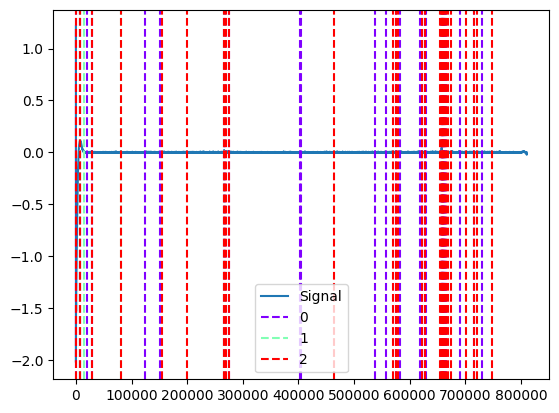

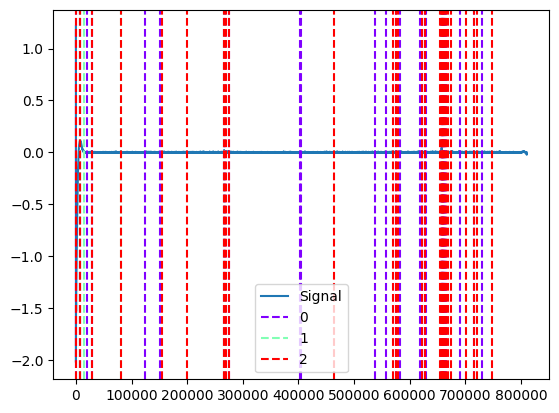

In [ ]:
nk.events_plot([
    neurokit["SCR_Peaks"],
    kim2004["SCR_Peaks"],
    nabian2018["SCR_Peaks"]
], eda_phasic)

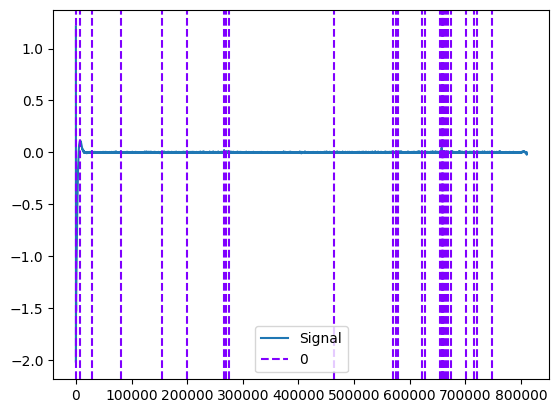

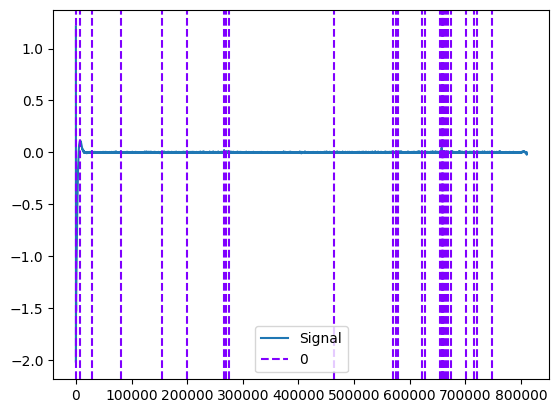

In [43]:
# _, neurokit = nk.eda_peaks(eda_phasic, sampling_rate=700, method="neurokit")

nk.events_plot([
    neurokit["SCR_Peaks"]
], eda_phasic)